In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

In [17]:
df = pd.read_csv('Tasas de interés.csv', sep=",")

In [18]:
df.columns

Index(['Periodo(MMM DD, AAAA)',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 1 año',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 5 años',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 10 años',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), UVR - 1 año',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), UVR - 5 años',
       'Tasa de interés Cero Cupón, Títulos de Tesorería (TES), UVR - 10 años'],
      dtype='object')

In [19]:

df['Fecha'] = pd.to_datetime(df['Periodo(MMM DD, AAAA)'], errors='coerce')
df = df.dropna(subset=['Fecha']).sort_values('Fecha')

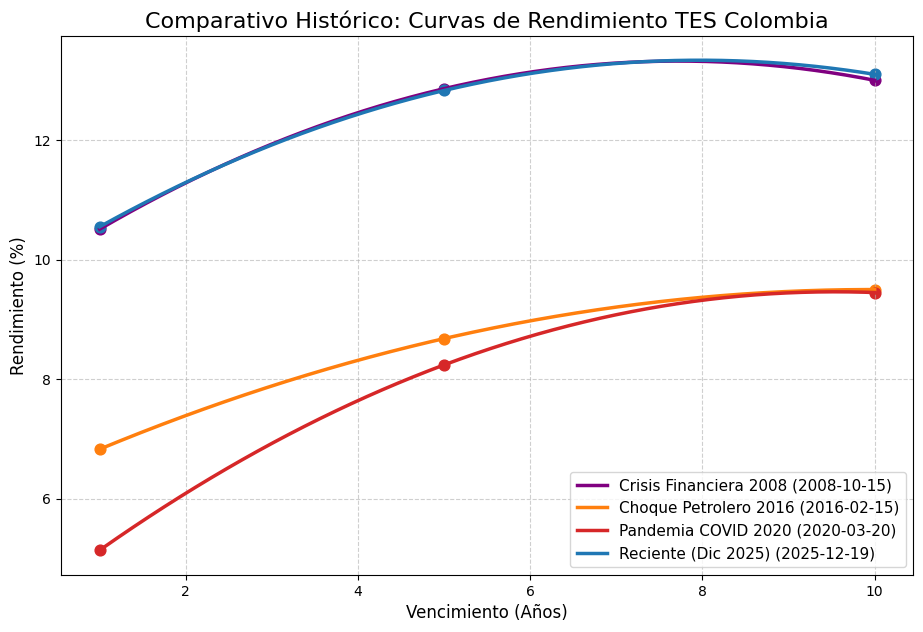

In [21]:
# Función para buscar la fecha más cercana disponible en el archivo
def buscar_datos(fecha_objetivo):
    target = pd.to_datetime(fecha_objetivo)
    idx = (df['Fecha'] - target).abs().idxmin() # Encuentra el índice más cercano
    return df.loc[idx]

# 2. Definir los 4 eventos históricos
eventos = {
    'Crisis Financiera 2008': '2008-10-15',
    'Choque Petrolero 2016': '2016-02-15',
    'Pandemia COVID 2020': '2020-03-20',
    'Reciente (Dic 2025)': df['Fecha'].iloc[-1] # La última fecha del archivo
}

# Configuración de la gráfica
plt.figure(figsize=(11, 7))
colores = ['#800080', '#ff7f0e', '#d62728', '#1f77b4'] # Morado, Naranja, Rojo, Azul

# 3. Iterar y graficar cada evento
for i, (nombre, fecha) in enumerate(eventos.items()):
    datos = buscar_datos(fecha)
    
    # Extraer puntos (1, 5, 10 años)
    plazos = np.array([1, 5, 10])
    tasas = np.array([
        datos['Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 1 año'],
        datos['Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 5 años'],
        datos['Tasa de interés Cero Cupón, Títulos de Tesorería (TES), pesos - 10 años']
    ])
    
    # Suavizar con Spline
    plazos_suaves = np.linspace(1, 10, 300)
    spline = make_interp_spline(plazos, tasas, k=2)
    tasas_suaves = spline(plazos_suaves)
    
    # Graficar curva y puntos
    fecha_real = datos['Fecha'].strftime('%Y-%m-%d')
    plt.plot(plazos_suaves, tasas_suaves, label=f"{nombre} ({fecha_real})", color=colores[i], linewidth=2.5)
    plt.scatter(plazos, tasas, color=colores[i], s=60)

# 4. Decoración final
plt.title('Comparativo Histórico: Curvas de Rendimiento TES Colombia', fontsize=16)
plt.xlabel('Vencimiento (Años)', fontsize=12)
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('curvas_rendimiento_tes_colombia.png', dpi=300)
plt.show()